# Teste de granularidade para modelos de ML

## Bibliotecas

In [67]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from keras.models import Model
from keras.layers import Input, Dense, GRU as GRU_layer
from keras.layers import Flatten,  Dropout
from tensorflow import cast, float32,reduce_mean,maximum
import tensorflow as tf
from keras.backend import epsilon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle
import optuna


## carregando os dados

In [68]:


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


## Analise exploratória para redução de dados
Ao fazer a analise, entende-se que os dados possuem variancias bem distintas e escolhe-se alguns exemplares para fazer os experimentos


Instituições com poucos dados: 5
Instituições com pelo menos 1 nulo: 0
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 111
Instituições restantes: 167


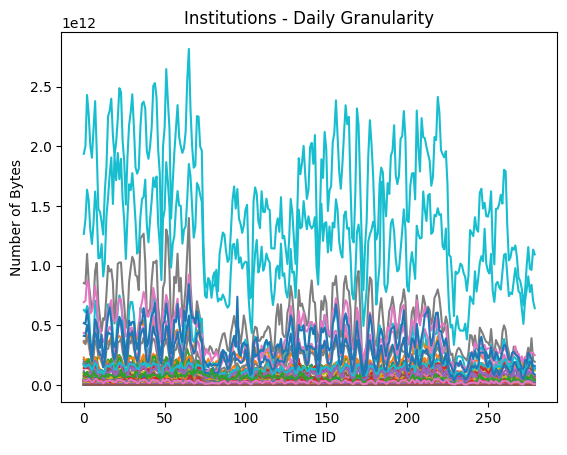

In [69]:
import matplotlib.pyplot as plt
import numpy as np
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.10)
    Q3 = instituicao["n_bytes"].quantile(0.90)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        #print(f"{i} tem outliers")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com pelo menos 1 nulo: {val_null}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")

for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]
  
print()

## Funções tratamento e separação de dados

In [9]:


def treino_val_teste(df = pd.Series, t_treino = 0, t_teste = 0, t_val = 0):
    return  df[:int(t_treino*len(df))], df[int(t_treino*len(df)):int((t_treino + t_val)*len(df))]  , df[int((t_treino + t_val)*len(df)):]

def scaling(df_series: pd.Series, mode = 0, scaler = None) -> pd.Series:
    if mode == 0:
        scaler = MinMaxScaler()
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.fit_transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name),scaler
    elif mode == 1:
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name)     

def sliding_window (df_series: pd.Series, inputs: int, outputs: int):

    total_window_size = inputs + outputs
    
    # 1. Validação
    if len(df_series) < total_window_size:
        print(f"Erro: Tamanho dos dados ({len(df_series)}) é menor que a janela total ({total_window_size})")
        return pd.DataFrame() # Retorna um DataFrame vazio

    # 2. Cria as janelas (sliding windows)
    windowed_data = []
    # Itera do primeiro índice inicial possível até o último
    for i in range(len(df_series) - total_window_size + 1):
        # A fatia vai de 'i' até 'i + tamanho_total'
        window_slice = df_series.iloc[i : i + total_window_size].values
        windowed_data.append(window_slice)

    # 3. Define os nomes das colunas
    x_cols = [f"x_{j}" for j in range(inputs)]
    y_cols = [f"y_{o}" for o in range(outputs)]
    
    # 4. Cria o DataFrame final
    df_windowed = pd.DataFrame(windowed_data, columns=x_cols + y_cols)
    return df_windowed


## Tratando [DIA] e separando em treino, val e teste

In [7]:


inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
train_list = []
val_list = []
test_list = []
#inst = inst_hour #SÓ DESCOMENTE ISSO DEPOIS DE TER RODADO A CELULA DE HORAS
for i in inst:
    print(i)
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)
        train_day_ = sliding_window(df_series = train_day, inputs = inputs_day, outputs = outputs_day)
        train_day_.insert(0, "id_institution", i)
        train_list.append(train_day_)

        test_day_ = sliding_window(df_series = test_day, inputs = inputs_day, outputs = outputs_day)
        test_day_.insert(0, "id_institution", i)
        test_list.append(test_day_)

        val_day_ = sliding_window(df_series = val_day, inputs = inputs_day, outputs = outputs_day)
        val_day_.insert(0, "id_institution", i)
        val_list.append(val_day_)

    else: print(f"   dataset pequeno ({tamanho})")
train_day_wind = pd.concat(train_list, ignore_index=True)
val_day_wind = pd.concat(val_list, ignore_index=True)
test_day_wind = pd.concat(test_list, ignore_index=True)
inst_day = list(train_day_wind["id_institution"].unique())
print("\n\n" + str(len(inst_day)))
del train_list, val_list, test_list
train_day_wind.to_csv('../../data/Tabelas_criadas/treino_dia.csv', index = False)
test_day_wind.to_csv('../../data/Tabelas_criadas/teste_dia.csv', index = False)
val_day_wind.to_csv('../../data/Tabelas_criadas/val_dia.csv', index = False)


252
98
73
93
239
60
113
27
74
53
147
193
240
40
130
230
62
179
102
12
71
205
161
6
83
132
100
149
117
156
41
165
222
39
84
190
224
0
155
9
169
52
158
143
254
34
173
107
138
208
32
86
137
57
201
192
105
50
168
223
64
119
55
196
167
10
80
79
178
246
180
145
213
115
220
238
16
111
164
175
72
5
25
123
76
152
232
48
207
70
4
216
31
151
68
54
95
218
133
46
214
112
106
35
215
244
120
104
235
183
243
24
67
42
172
38
56
225
228
217
219
191
94
82
200
144
118
63
22
23
75
45
65
141
101
126
114
203
108
136
284
88
28
3
109
30
8
221
150
125
177
198
248
66
249
171
59
189
69
185


160


## Tratando [HORAS] e separando em treino, val e teste

In [10]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora.csv', index = False)

252
98
   dataset pequeno (0)
73
93
239
   dataset pequeno (0)
60
113
   dataset pequeno (0)
27
   dataset pequeno (0)
74
   dataset pequeno (0)
53
147
   dataset pequeno (0)
193
240
   dataset pequeno (0)
40
   dataset pequeno (0)
130
   dataset pequeno (0)
230
   dataset pequeno (0)
62
179
   dataset pequeno (0)
102
   dataset pequeno (0)
12
   dataset pequeno (0)
71
   dataset pequeno (0)
205
161
   dataset pequeno (0)
6
   dataset pequeno (0)
83
   dataset pequeno (0)
132
   dataset pequeno (0)
100
   dataset pequeno (0)
149
117
   dataset pequeno (0)
156
41
165
   dataset pequeno (0)
222
39
84
190
   dataset pequeno (0)
224
   dataset pequeno (0)
0
   dataset pequeno (0)
155
   dataset pequeno (0)
9
   dataset pequeno (0)
169
52
   dataset pequeno (0)
158
   dataset pequeno (0)
143
254
34
173
   dataset pequeno (0)
107
   dataset pequeno (0)
138
   dataset pequeno (0)
208
   dataset pequeno (0)
32
   dataset pequeno (0)
86
   dataset pequeno (0)
137
57
   dataset pequeno (0)
201
1

## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [ ]:


inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)
        test_10min = scaling(_test_hour,1,scaler)
        val_10min = scaling(_val_hour,1,scaler)
        train_10min_ = sliding_window(df_series = train_10min, inputs = inputs_10min, outputs = outputs_10min)
        train_10min_["id_institution"] = i
        train_list.append(train_10min_)

        test_10min_ = sliding_window(df_series = test_10min, inputs = inputs_10min, outputs = outputs_10min)
        test_10min_["id_institution"] = i
        test_list.append(test_10min_)
        val_10min_ = sliding_window(df_series = val_10min, inputs = inputs_10min, outputs = outputs_10min)
        val_10min_["id_institution"] = i
        val_list.append(val_10min_)
    else: print(f"   dataset pequeno ({tamanho})")

train_10min_wind = pd.concat(train_list, ignore_index=True)
val_10min_wind = pd.concat(val_list, ignore_index=True)
test_10min_wind = pd.concat(test_list, ignore_index=True)
inst_10min = list(train_10min_wind["id_institution"].unique())
print("\n\n" + str(len(inst_10min)))


train_10min_wind.to_csv('../../data/Tabelas_criadas/treino_10min.csv', index = False)
test_10min_wind.to_csv('../../data/Tabelas_criadas/teste_10min.csv', index = False)
val_10min_wind.to_csv('../../data/Tabelas_criadas/val_10min.csv', index = False)

192
249
71
205
148
   dataset pequeno (0)
184
125
164
97
56


9


## Dados já carregados

In [15]:
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora.csv')
test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora.csv')
val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora.csv')
inputs_hour = 7*24
outputs_hour = 1*24

train_day_wind = pd.read_csv('../../data/Tabelas_criadas/treino_dia.csv')
test_day_wind = pd.read_csv('../../data/Tabelas_criadas/teste_dia.csv')
val_day_wind = pd.read_csv('../../data/Tabelas_criadas/val_dia.csv')
inputs_day = 7
outputs_day = 1

np_train_d = np.array(train_day_wind)
np_test_d = np.array(test_day_wind)
np_val_d = np.array(val_day_wind)
X_train_d = np_train_d[:, :inputs_day + 1].astype('float32')
y_train_d = np_train_d[:, inputs_day+1:].astype('float32')
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+y_train_d.shape[1],0]].astype('float32')
X_val_d = np_val_d[:, :inputs_day + 1].astype('float32')
y_val_d = np_val_d[:, inputs_day+1:].astype('float32')


np_train_h = np.array(train_hour_wind)
np_test_h = np.array(test_hour_wind)
np_val_h = np.array(val_hour_wind)
X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')

## Funções de modelos preditivos

In [16]:
# For Graphs plotting and training time evaluation
import pylab as plt

def generate_GRU(n_timesteps, n_features, n_outputs, dropout_rate=0.2, gru_units=64):
    """
    Cria um modelo GRU puro.
    
    n_timesteps: Comprimento da sequência temporal (no seu caso, 1)
    n_features: Quantidade de colunas/variáveis de entrada
    n_outputs: Quantidade de valores a prever
    """
    
    # Camada de Entrada
    inp = Input(shape=(n_timesteps, n_features))
    
    # Camada GRU
    # return_sequences=False pois queremos apenas o vetor final para a Dense
    # 64 unidades é um bom ponto de partida (mais robusto que 8)
    x = GRU_layer(gru_units, return_sequences=False)(inp) 
    
    # Dropout para evitar overfitting
    x = Dropout(dropout_rate)(x)
    
    # Camada de Saída
    # activation='linear' é o padrão para regressão. 
    # Se seus dados Y foram normalizados entre 0 e 1, você pode usar 'sigmoid'.
    out = Dense(n_outputs, activation='linear')(x)
    
    model = Model(inputs=inp, outputs=out)
    return model



from statsmodels.tsa.statespace.sarimax import SARIMAX

def generate_SARIMA_model(order, seasonal_order, X_train):
    """
    Cria um modelo SARIMA com os parâmetros fornecidos.
    
    order: tupla (p,d,q)
    seasonal_order: tupla (P,D,Q,s)
    X_train: série temporal de treino
    """
    model = SARIMAX(
        X_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model

def generate_MLP_model(max_seq, output):
    ip = Input(shape=(max_seq,))
    y= Dropout(0.1)(ip)
    y = Flatten()(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation='relu')(y)
    y = Dropout(0.2)(y)
    y = Dense(500, activation = 'relu')(y)
    y = Dropout(0.3)(y)
    out = Dense(output, activation='linear')(y)
    model = Model(ip, out)
    model.summary()
    return model

def get_nrmse(global_range):
    def nrmse(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Calcular o RMSE matematicamente
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        rmse = tf.sqrt(mse)
        
        # Usa a amplitude global fixa em vez de calcular por lote!
        return rmse / global_range
    
    # Renomeia a função interna para ficar bonito no log do Keras
    nrmse.__name__ = 'nrmse'
    return nrmse

def smape(y_true, y_pred):
    y_true = cast(y_true, float32)
    y_pred = cast(y_pred, float32)
    diff = abs(y_true - y_pred)
    add = abs(y_true) + abs(y_pred)
    # epsilon é usado para evitar divisão por zero
    return 100.0 * reduce_mean(diff / maximum(add, epsilon()))

In [39]:
def criar_e_treinarMLP(dimensao,input_len, output_len,X_train,y_train, X_val, y_val, epochs, batch_size, path_modelo, path_metricas,plot = True,):
    print("criando modelo...")
    mlp = generate_MLP_model(input_len,output_len)
    print("compilando modelo...")
    mlp.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse,
                smape
            ]
    )
    print("treinando modelo...")
    history = mlp.fit(
        X_train, 
        y_train, 
        epochs=10, # Comece com poucas epochs (ex: 10) e aumente se necessário
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1 # Mostra a barra de progresso
    )
    print(
        f"modelo treinado!\
        \nResultado:\
        \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
        \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
        \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
        \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
          )
    
    if plot:
        plt.title(label= 'MLP Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='MLP Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='MLP Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='MLP Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    
    mlp.save(path_modelo)
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": "MLP"
            ,"DIM": dimensao
            ,"RMSE": history.history["val_rmse"][-1]
            ,"MAE": history.history["val_mae"][-1]
            ,"NMRSE": history.history['val_nrmse'][-1]
            ,"SMAPE": history.history['val_smape'][-1]
            }

        df = pd.DataFrame(dict_model).set_index("idx")
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarGRU(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                        gru_units, 
                        path_modelo, 
                        path_metricas = None,
                        plot = True,
                        verbose = True):
    print("criando modelo...")
    gru = generate_GRU(1,input_len,output_len, dropout_rate, gru_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    gru.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = gru.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'GRU Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='GRU Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='GRU Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='GRU Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        gru.save(path_modelo)
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["GRU"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history


def criar_e_treinarSARIMA(dimensao, order, seasonal_order, X_train, y_train, X_val, y_val, path_modelo, path_metricas, plot=True):
    print("criando modelo SARIMA...")
    sarima = generate_SARIMA_model(order, seasonal_order, X_train)
    
    print("treinando modelo SARIMA...")
    sarima_fit = sarima.fit(disp=False)
    
    # Previsões
    y_pred_train = sarima_fit.predict(start=0, end=len(y_train)-1)
    y_pred_val = sarima_fit.predict(start=len(y_train), end=len(y_train)+len(y_val)-1)
    
    # Métricas
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    nrmse_train = rmse_train / (max(y_train) - min(y_train))
    nrmse_val = rmse_val / (max(y_val) - min(y_val))
    smape_train = smape(y_train, y_pred_train)
    smape_val = smape(y_val, y_pred_val)  
    
    print(
        f"modelo treinado!\
        \nResultado:\
        \nRMSE:\n   treino:{rmse_train}   val:{rmse_val}\
        \nMAE:\n    treino:{mae_train}   val:{mae_val}\
        \nMAE:\n    treino:{nrmse_train}   val:{nrmse_val}\
        \nMAE:\n    treino:{smape_train}   val:{smape_val}"
    )
    
    # Salvando modelo
    sarima_fit.save(path_modelo)
    
    # Salvando métricas
    dict_model = {
        "MODELO": ["SARIMA"],
        "DIM": [dimensao],
        "RMSE": [rmse_val],
        "MAE": [mae_val],
        "NRMSE": [nrmse_val],
        "SMAPE": [smape_val]
    }
    
    df = pd.DataFrame([dict_model])
    header_condition = not os.path.exists(path_metricas)
    df.to_csv(path_metricas, index=False, mode="a", header=header_condition)
    
    return sarima_fit




## Treinando os modelos

In [ ]:


def otimizar_GRU(X_train, y_train, X_val, y_val, dimensao, input_len, output_len):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 50, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        gru_units = trial.suggest_int('gru_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarGRU(
                dimensao=dimensao,
                input_len=input_len+1,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                gru_units=gru_units,
                path_modelo=f'../../MODELOS/GRU_{dimensao}.keras',
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_GRU")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    gru = generate_GRU(1, input_len+1, output_len, study.best_params['dropout_rate'], study.best_params['gru_units'])
    gru.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(np.max(y_train) - np.min(y_train)),
                smape
            ]
    )
    gru.fit(
        X_train, 
        y_train, 
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        validation_data=(X_val, y_val),
        verbose=1
    )
    gru.save(f'../../MODELOS/GRU_{dimensao}_otimizada.keras')
    return study





[I 2026-03-09 12:22:23,568] A new study created in memory with name: Otimizacao_GRU
[I 2026-03-09 12:22:23,571] Trial 0 pruned. 
[I 2026-03-09 12:22:23,572] Trial 1 pruned. 
[I 2026-03-09 12:22:23,573] Trial 2 pruned. 
[I 2026-03-09 12:22:23,574] Trial 3 pruned. 
[I 2026-03-09 12:22:23,574] Trial 4 pruned. 
[I 2026-03-09 12:22:23,575] Trial 5 pruned. 
[I 2026-03-09 12:22:23,575] Trial 6 pruned. 
[I 2026-03-09 12:22:23,575] Trial 7 pruned. 
[I 2026-03-09 12:22:23,576] Trial 8 pruned. 
[I 2026-03-09 12:22:23,577] Trial 9 pruned. 
[I 2026-03-09 12:22:23,583] Trial 10 pruned. 
[I 2026-03-09 12:22:23,586] Trial 11 pruned. 
[I 2026-03-09 12:22:23,589] Trial 12 pruned. 
[I 2026-03-09 12:22:23,592] Trial 13 pruned. 
[I 2026-03-09 12:22:23,594] Trial 14 pruned. 
[I 2026-03-09 12:22:23,597] Trial 15 pruned. 
[I 2026-03-09 12:22:23,600] Trial 16 pruned. 
[I 2026-03-09 12:22:23,603] Trial 17 pruned. 
[I 2026-03-09 12:22:23,606] Trial 18 pruned. 
[I 2026-03-09 12:22:23,608] Trial 19 pruned. 


ValueError: No trials are completed yet.

In [ ]:
study_d = otimizar_GRU(X_train_d, y_train_d, X_val_d, y_val_d, "Diária", inputs_day, outputs_day)

In [31]:
study_h = otimizar_GRU(X_train_h, y_train_h, X_val_h, y_val_h, "Horária", inputs_hour, outputs_hour)

[I 2026-03-08 12:29:03,592] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:43:32,191] Trial 0 finished with value: 0.053839121013879776 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.43514317372010325, 'gru_units': 38}. Best is trial 0 with value: 0.053839121013879776.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 12:46:53,962] Trial 1 finished with value: 0.053716111928224564 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.39820049844988603, 'gru_units': 78}. Best is trial 1 with value: 0.053716111928224564.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:45:28,367] Trial 18 finished with value: 0.05327552184462547 and parameters: {'batch_size': 16, 'epochs': 50, 'dropout_rate': 0.25956335507710704, 'gru_units': 89}. Best is trial 17 with value: 0.052590757608413696.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-08 15:48:43,602] Trial 19 finished with value: 0.05541747808456421 and parameters: {'batch_size': 64, 'epochs': 40, 'dropout_rate': 0.32372068530860193, 'gru_units': 68}. Best is trial 17 with value: 0.052590757608413696.



Melhor NRMSE: 0.052590757608413696
Melhores parâmetros: {'batch_size': 16, 'epochs': 40, 'dropout_rate': 0.2368420652728273, 'gru_units': 107}


criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.16324685513973236   val:0.17333801090717316            
MAE:
    teste:0.12356386333703995   val:0.13126246631145477            
NRMSE:
  teste:0.1590331494808197   val:0.16326577961444855            
SMAPE:
  teste:25.927919387817383   val:28.794567108154297


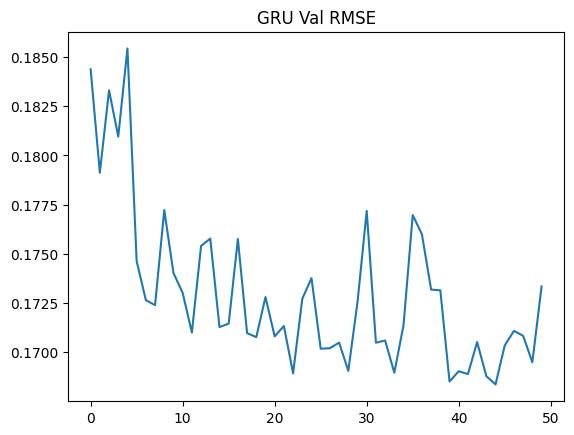

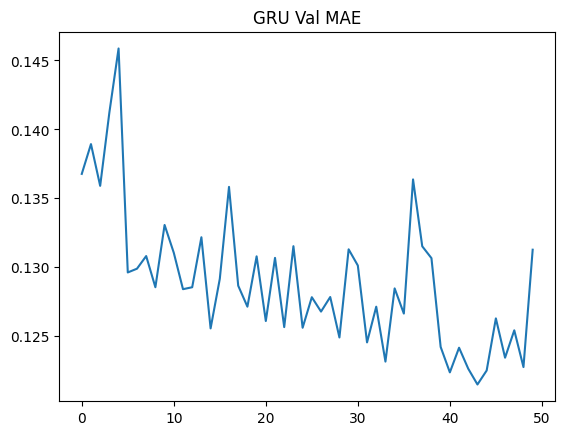

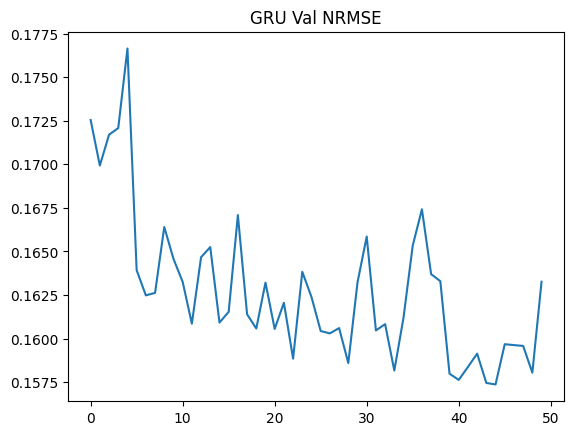

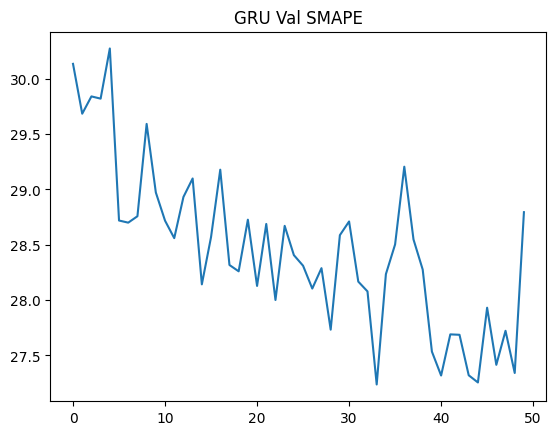

In [ ]:
criar_e_treinarGRU(
    dimensao="Diária",
    input_len=inputs_day+1,
    output_len=outputs_day,
    X_train=X_train_d,
    y_train=y_train_d,
    X_val=X_val_d,
    y_val=y_val_d,
    epochs=study_d.best_params['epochs'],
    batch_size=study_d.best_params['batch_size'],
    dropout_rate=study_d.best_params['dropout_rate'],
    gru_units=study_d.best_params['gru_units'],
    path_modelo=f'../../MODELOS/GRU_Diaria_otimizada.keras',
    plot=True,
    verbose=True
)

criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.07017677277326584   val:0.06407495588064194            
MAE:
    teste:0.04234971106052399   val:0.03652589023113251            
NRMSE:
  teste:0.06903231889009476   val:0.052524883300065994            
SMAPE:
  teste:41.69716262817383   val:39.09824752807617


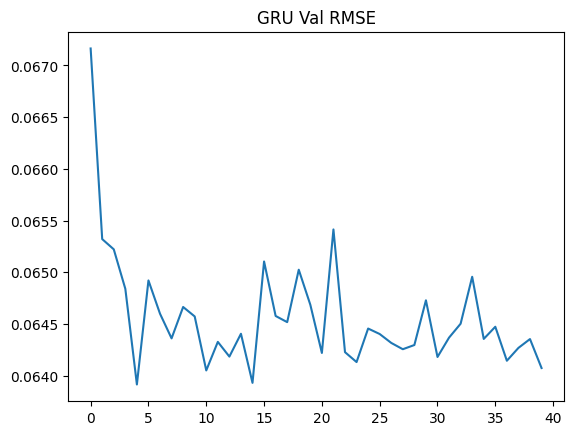

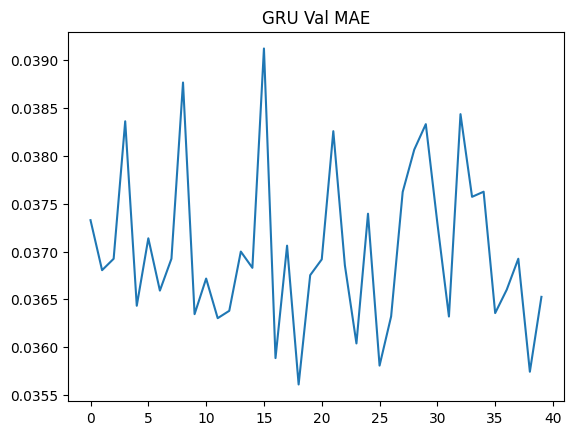

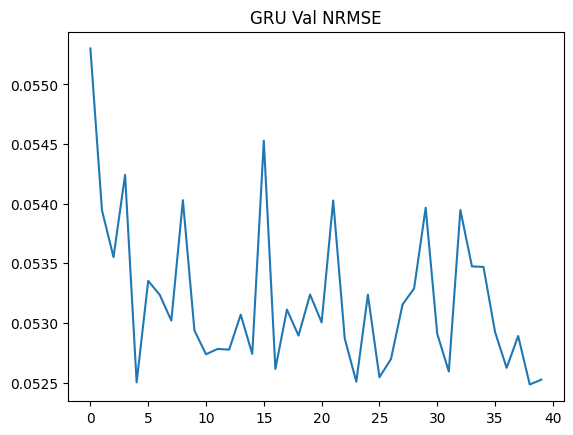

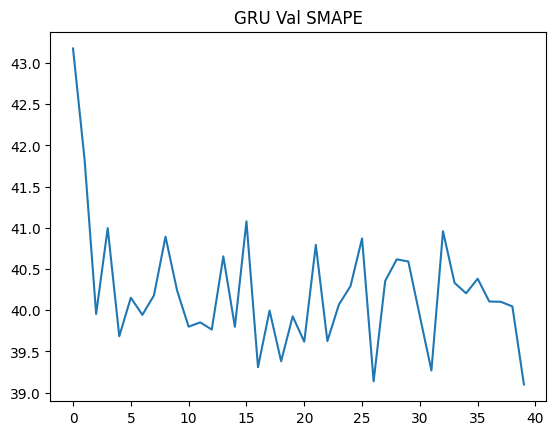

In [35]:
# Treinamento dos modelos para a granularidade horária
criar_e_treinarGRU(
    dimensao="Horária",
    input_len=inputs_hour + 1,
    output_len=outputs_hour,
    X_train=X_train_h,
    y_train=y_train_h,
    X_val=X_val_h,
    y_val=y_val_h,
    epochs=study_h.best_params['epochs'],
    batch_size=study_h.best_params['batch_size'],
    dropout_rate=study_h.best_params['dropout_rate'],
    gru_units=study_h.best_params['gru_units'],
    path_modelo='../../MODELOS/GRU_horaria_otimizada.keras',
    plot=True
)

In [ ]:
criar_e_treinarSARIMA(
    dimensao= "diaria",
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    X_train=y_train_d.flatten(),
    y_train=y_train_d.flatten(),
    X_val=y_val_d.flatten(),
    y_val=y_val_d.flatten(),
    path_modelo='../../MODELOS/SARIMA_diaria.pkl',
    path_metricas='../../MODELOS/metricas.csv',
    plot=True
    
)

TypeError: criar_e_treinarSARIMA() missing 9 required positional arguments: 'dimensao', 'order', 'seasonal_order', 'X_train', 'y_train', 'X_val', 'y_val', 'path_modelo', and 'path_metricas'

: 

In [ ]:
criar_e_treinarSARIMA(
    dimensao= "horaria",
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    X_train=y_train_h.flatten(),
    y_train=y_train_h.flatten(),
    X_val=y_val_h.flatten(),
    y_val=y_val_h.flatten(),
    path_modelo='../../MODELOS/SARIMA_horaria.pkl',
    path_metricas='../../MODELOS/metricas.csv',
    plot=True
    
)

## Carregando modelos

In [50]:
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

def avaliar_modelo(y_real, y_previsto, verbose = False):
    mse = mean_squared_error(y_real, y_previsto)
    rmse = math.sqrt(mse)
    nrmse = rmse / (max(y_real) - min(y_real))
    mae = mean_absolute_error(y_real, y_previsto)
    _smape = smape(y_real, y_previsto) 
    if verbose:
        print(f"--- Desempenho: ---")
        print(f"RMSE (Erro Médio): {rmse:.4f}")
        print(f"MAE  (Erro Absoluto): {mae:.4f}")
        print(f"SMAPE: {_smape:.4f}")
        print(f"NRMSE: {nrmse:.4f}")
        print("-" * 30)
    return np.array([rmse, mae, nrmse, _smape])

def comparar_desempeho_granularidade(X_test_d, X_test_h, y_test_d, y_test_h, MODELO_d, MODELO_h):
    print("Carregando modelos...")
    y_pred_d = MODELO_d.predict(X_test_d)
    y_pred_h = MODELO_h.predict(X_test_h)
    
    print(f"Desempenho do modelo para granularidade diária:")
    resultado_d = avaliar_modelo(y_test_d.flatten(), y_pred_d.flatten(), verbose=True)
    
    print(f"Desempenho do modelo para granularidade horária:")
    resultado_h = avaliar_modelo(y_test_h.flatten(), y_pred_h.flatten(), verbose=True)
    
    return [resultado_d, resultado_h]


def avaliar_modelo_inst(inst:list,X_test_d, X_test_h, y_test_d, y_test_h, modelo_d, modelo_h):
    resultados = {
        "instituição": [],
        "granularidade:": [],
        "MAE": [],
        "RMSE": [],
        "NRMSE": [],
        "SMAPE": []
    }
    def separar_dados_por_instituicao(inst, X_test, y_test):
        idx = np.where(X_test[:,0] == inst)[0]
        X_test_i = X_test[idx]
        y_test_i = y_test[idx]
        return X_test_i, y_test_i
    for i in inst:
        print(f"\n##############################\n \
Avaliando instituição {i}... \
                \n##############################\n")
        X_test_d_i, y_test_d_i = separar_dados_por_instituicao(i, X_test_d, y_test_d)
        X_test_h_i, y_test_h_i = separar_dados_por_instituicao(i, X_test_h, y_test_h)
        resultado = comparar_desempeho_granularidade(X_test_d_i, X_test_h_i, y_test_d_i, y_test_h_i, modelo_d, modelo_h)
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("diária")
        resultados["MAE"].append(resultado[0][1])
        resultados["RMSE"].append(resultado[0][0])
        resultados["NRMSE"].append(resultado[0][2])
        resultados["SMAPE"].append(resultado[0][3])
        
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("horária")
        resultados["MAE"].append(resultado[1][1])
        resultados["RMSE"].append(resultado[1][0])
        resultados["NRMSE"].append(resultado[1][2])
        resultados["SMAPE"].append(resultado[1][3])
    return pd.DataFrame(resultados)



        
        



In [42]:
gru_diaria = load_model('../../MODELOS/GRU_diaria_otimizada.keras', compile=False)
gru_horaria = load_model('../../MODELOS/GRU_horaria_otimizada.keras', compile=False)
resultado_geral =comparar_desempeho_granularidade(
    X_test_d.reshape((X_test_d.shape[0], 1, X_test_d.shape[1])),
    X_test_h.reshape((X_test_h.shape[0], 1, X_test_h.shape[1])),
    y_test_d[:,0], 
    y_test_h[:,:24], 
    gru_diaria, 
    gru_horaria
    )
#avaliar_modelo_inst(inst_day, X_test_d, X_test_h, y_test_d, y_test_h, gru_diaria, gru_horaria)

Carregando modelos...
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 1s 477us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1494
MAE  (Erro Absoluto): 0.1162
SMAPE: 37.5851
NRMSE: 0.0897
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0600
MAE  (Erro Absoluto): 0.0312
SMAPE: 44.0314
NRMSE: 0.0172
------------------------------


In [51]:
inst_day = list(test_day_wind["id_institution"].unique())

df =avaliar_modelo_inst(inst_day,
                    X_test_d.reshape((X_test_d.shape[0], 1, X_test_d.shape[1])), 
                    X_test_h.reshape((X_test_h.shape[0], 1, X_test_h.shape[1])), 
                    y_test_d[:,0], 
                    y_test_h[:,:24], 
                    gru_diaria, 
                    gru_horaria)

display(df)


##############################
 Avaliando instituição 189...                 
##############################

Carregando modelos...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1357
MAE  (Erro Absoluto): 0.1197
SMAPE: 71.7330
NRMSE: 0.2415
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0243
MAE  (Erro Absoluto): 0.0134
SMAPE: 87.0548
NRMSE: 0.0760
------------------------------

##############################
 Avaliando instituição 68...                 
##############################

Carregando modelos...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1029
MAE  (Erro Absoluto): 0.0847
SMAPE: 26.0066
NRMSE: 0.4237
------------------------------
Desempenho do modelo para gra

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
0,189,diária,0.119681,0.135679,0.241493,71.733047
1,189,horária,0.013440,0.024318,0.075995,87.054756
2,68,diária,0.084707,0.102925,0.423729,26.006598
3,68,horária,0.038114,0.048071,0.140482,15.630311
4,217,diária,0.204103,0.273591,0.217273,44.121128
...,...,...,...,...,...,...
329,76,horária,0.019418,0.038876,0.082688,55.424767
330,118,diária,0.114414,0.136448,0.228537,12.199168
331,118,horária,0.088755,0.115589,0.159500,17.534832
332,104,diária,0.111729,0.136523,0.212420,26.018604


In [66]:
df.to_csv('../../RESULTADOS/avaliacao_por_instituicao.csv', index = False)

In [65]:
df[(df['NRMSE'] >= 1)]

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
90,62,diária,0.115442,0.131275,1.694386,58.937145
108,38,diária,0.084423,0.085504,2.621264,96.992065
174,177,diária,0.090171,0.090763,1.801061,79.380402
296,141,diária,0.091681,0.094684,1.122402,81.725952
308,243,diária,0.080248,0.080248,32605.832031,100.000000
309,243,horária,0.012537,0.014538,7568.569824,99.723816


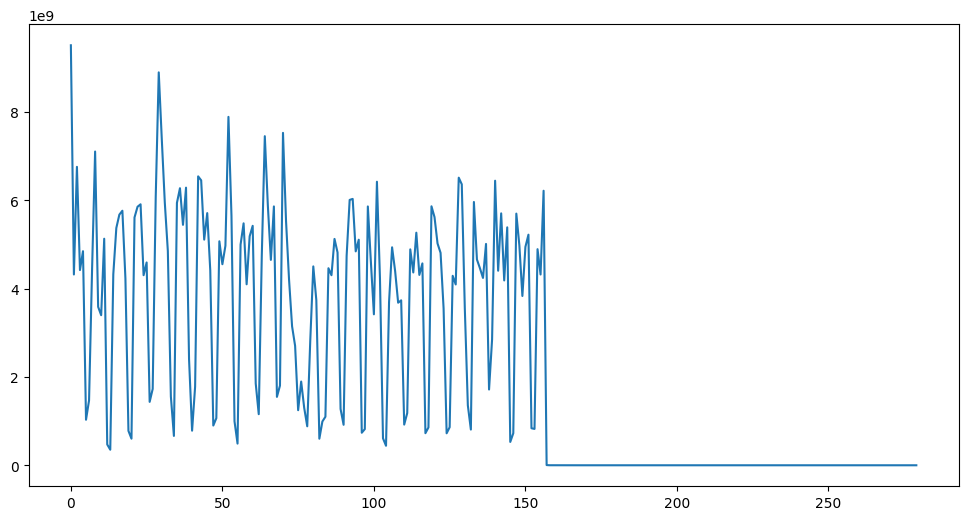

In [93]:
# 1. Filtre o DataFrame uma única vez
df_inst_243 = df_day[df_day['id_institution'] == '243']

# 2. Passe as colunas de tempo (x) e bytes (y) diretamente
plt.figure(figsize=(12, 6))
plt.plot(df_inst_243['id_time'], df_inst_243['n_bytes'])

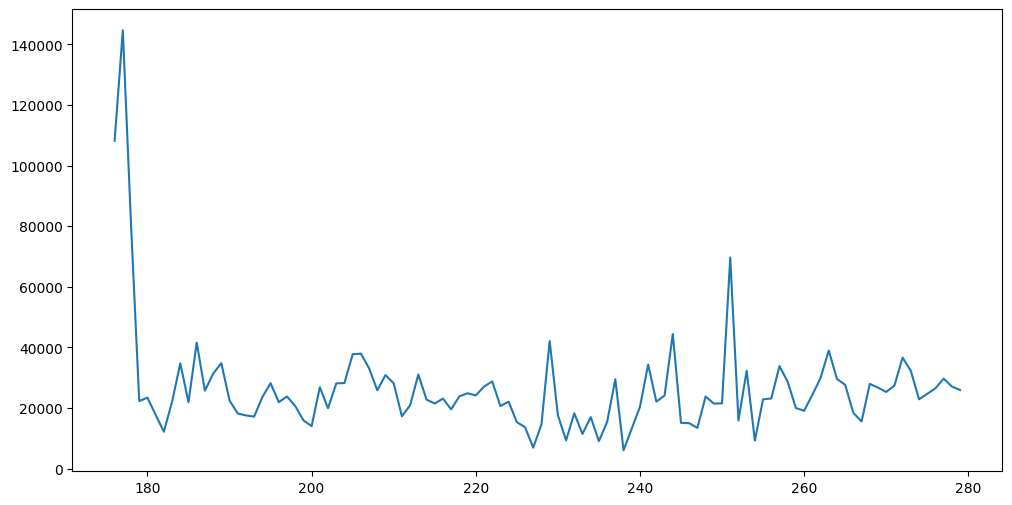

In [91]:
# 2. Passe as colunas de tempo (x) e bytes (y) diretamente
plt.figure(figsize=(12, 6))
plt.plot(df_inst_243[df_inst_243['id_time'] > 175]['id_time'], df_inst_243[df_inst_243['id_time'] > 175]['n_bytes'])

In [79]:
df_inst_243.tail(10)

,id_time,n_bytes,id_institution
72218,270,25309,243
72219,271,27412,243
72220,272,36631,243
72221,273,32279,243
72222,274,22878,243
72223,275,24693,243
72224,276,26496,243
72225,277,29705,243
72226,278,27094,243
72227,279,25954,243
